In [7]:
using ITensors, ITensorMPS
using ITransverse
using ITensorExpMPO
using ITensors: Algorithm
using Plots
using Plots.PlotMeasures
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)


using LsqFit

using Revise
includet("main.jl")

In [2]:
lambda = 1.0 # Critical point

1.0

Hamiltonian of the Alcaraz Model given by:

$$H = -\sum_i \left( \sigma_i^z \sigma_{i+1}^z + \lambda \sigma_i^x \mathbf{+} p (\sigma_i^z \sigma_{i+2}^z + \lambda \sigma_i^x \sigma_{i+1}^x \right))$$

In [3]:
function build_alcaraz_H(sites, lambda, p)
    N = length(sites)
    os = OpSum()

    # Open boundary conditions
    
    # Transverse field applies to all sites (on-site term)
    for i in 1:N
        os += -lambda, "X", i
    end
    
    # Nearest neighbor terms
    for i in 1:(N-1)
        os += -1.0, "Z", i, "Z", i+1
        os += -p * lambda, "X", i, "X", i+1
    end
    
    # Next-nearest neighbor terms
    for i in 1:(N-2)
        os += -p, "Z", i, "Z", i+2
    end
    
    return MPO(os, sites)
end

build_alcaraz_H (generic function with 1 method)

## Diagnosing Convergence: The Spectral Gap and Deflated Power Method

### 1. Motivation: Why Track the Spectral Gap?
In transverse contraction, the Power Method is used to find the dominant left and right eigenvectors ($|L_0\rangle$ and $|R_0\rangle$) of the transfer matrix $M$. The convergence rate of this method is strictly governed by the ratio of the two leading eigenvalues: $|\lambda_1 / \lambda_0|^k$. 

As the simulated quench time $T$ increases, the spectrum of the transfer matrix evolves. If the system approaches a dynamical phase transition or a severe entanglement barrier, the gap $\Delta = |\lambda_0| - |\lambda_1|$ can close. If $|\lambda_1| \to |\lambda_0|$, the Power Method requires exponentially more iterations to separate the states. If it hits the maximum iteration limit before fully converging, the resulting states are contaminated by excited states. Consequently, the extracted Renyi entropy profiles become physically meaningless. Tracking the exact gap allows us to detect when the Power Method is failing and guarantees the numerical integrity of the simulation.

In [3]:
# ALCARAZ MODEL

function compute_alcaraz_entropies(
    mpo_generator::Function, target_T::Float64;
    p::Float64=0.0, lambda::Float64=1.0,
    dt::Float64=0.1, cutoff::Float64=1e-12, maxdim::Int=256, 
    alg::String="RTM", eps_converged::Float64=1e-6, nbeta::Int=4
)

    Ntime_steps = round(Int, target_T / dt)
    Nsteps = Ntime_steps + nbeta
    dbeta = -im * dt

    s = Index(2, "S=1/2")
    # init_state = up_state         # why this fails?
    # init_state = complex(state(s, "X+"))
    init_state = complex([1,1] / sqrt(2))  # |X+> state in Z basis
    
    # Build tMPO blocks
    mp_alcaraz = AlcarazParams(lambda=lambda, p=p, phys_site=s)
    tp = tMPOParams(mp=mp_alcaraz; dt=dt, nbeta=nbeta, scheme=AlcarazVD2(), dbeta=dbeta, bl=init_state)   
    b = FwtMPOBlocks(tp)
    
    # Power Method Params
    pm_params = PMParams(;
        truncp = (; cutoff=cutoff, maxdim=maxdim, alg=alg), 
        opt_method = :nosym, 
        cutoffs = [cutoff], 
        maxdims = 2:2:maxdim, 
        itermax = 5000, 
        eps_converged = eps_converged, 
        normalization = "overlap",
        stuck_after = 200,
        compute_fidelity = true
    )

    # Dynamically determine spatial bond dimension
    dummy_sites = siteinds("S=1/2", 4) 
    sample_mpo = mpo_generator(dummy_sites, lambda, p; dt=dt)
    spatial_bond_dim = dim(linkind(sample_mpo, 1))

    time_sites  = addtags(siteinds(spatial_bond_dim, Nsteps; conserve_qns=false), "time")
    mpo         = fw_tMPO(b, time_sites, tr=init_state)
    start_mps   = fw_tMPS(b, time_sites; tr=init_state, LR=:right)

    # Run Power Method
    psi_L, psi_R, pm_info = ITransverse.powermethod_lr(start_mps, mpo, mpo, pm_params)

    # Normalize just in case
    norm = overlap_noconj(psi_L, psi_R)
    psi_L ./= sqrt(norm)
    psi_R ./= sqrt(norm)

    # Calculate entropy profiles (real & imaginary)
    p_r2_real = real.(ITransverse.gen_renyi2(psi_L, psi_R))
    p_r2_imag = imag.(ITransverse.gen_renyi2(psi_L, psi_R))

    bonds = 1:length(p_r2_real)

    return bonds, p_r2_real, p_r2_imag, psi_L, psi_R, mpo
end

compute_alcaraz_entropies (generic function with 1 method)

### 2. Obtaining the Dominant Eigenvalue ($\lambda_0$)
Assuming the base Power Method has converged, the dominant eigenvalue is simply the expectation value of the transfer matrix with respect to the dominant bi-orthogonal eigenstates:
$$ \lambda_0 = \frac{\langle L_0 | M | R_0 \rangle}{\langle L_0 | R_0 \rangle} $$

### 3. Isolating the First Excited State ($\lambda_1$) via Deflation
Because $M$ is non-Hermitian (a consequence of the $W^{II}$ algorithm and complex time steps), its left and right eigenvectors differ, satisfying the bi-orthogonality condition $\langle L_i | R_j \rangle = \delta_{ij}$. To find the first excited state, we construct a "deflated" transfer matrix that projects out the dominant state.

We begin by initializing a random MPS, which is mathematically a linear combination of all eigenvectors:
$$ |\psi_{rand}\rangle = c_0|R_0\rangle + c_1|R_1\rangle + c_2|R_2\rangle + c_3|R_3\rangle + \dots $$

If we apply the transfer matrix $M$ and subtract the projection along the dominant state, a single iteration yields:
$$ M|\psi_{rand}\rangle - \lambda_0 c_0 |R_0\rangle = c_1\lambda_1|R_1\rangle + c_2\lambda_2|R_2\rangle + c_3\lambda_3|R_3\rangle + \dots $$

While this perfectly kills the dominant state $|R_0\rangle$, the resulting state remains polluted by all higher excited states ($|R_2\rangle, |R_3\rangle$, etc.). To isolate strictly $|R_1\rangle$, we must loop the deflation process. Applying this deflated operator $k$ times yields:
$$ \lambda_1^k \left( c_1|R_1\rangle + c_2\left(\frac{\lambda_2}{\lambda_1}\right)^k|R_2\rangle + c_3\left(\frac{\lambda_3}{\lambda_1}\right)^k|R_3\rangle + \dots \right) $$

Because $|\lambda_1| > |\lambda_2| > |\lambda_3|$, the fraction $(\lambda_n / \lambda_1)^k$ decays to zero as $k$ increases. The loop acts as a geometric filter that exponentially crushes all higher excited states until only $|R_1\rangle$ survives, allowing us to compute $\lambda_1$ exactly.

### 4. Tensor Network Implementation Constraints
In standard linear algebra, deflation is a trivial matrix update. In the Matrix Product State (MPS) formalism, however, subtracting two quantum states adds their bond dimensions ($\chi_{\text{new}} = \chi_{\text{opsi}} + \chi_{\text{projpsi}}$). If left unchecked during the power method loop, memory requirements will explode exponentially. Therefore, every deflation step must be immediately followed by an SVD-based truncation (`truncate!`) to maintain a tractable bond dimension without losing the precision required to resolve the gap.

In [5]:
function gen_exc1_right(in_mpo::MPO, psi_L_0::MPS, psi_R_0::MPS, lambda0::Number, in_mps_R::MPS; pm_cutoff=1e-10)
    # Apply MPO
    opsi = applyn(in_mpo, in_mps_R; cutoff=pm_cutoff)

    n_opsi = norm(opsi)
    if n_opsi > 1e-25
        opsi ./= n_opsi
    else
        n_opsi = 1.0 # fallback
    end
    
    # Bi-orthogonal projection for the Right state and subtraction 
    # projpsi = lambda0 * overlap_noconj(psi_L_0, in_mps_R) * psi_R_0
    # opsi_proj = add(opsi, -projpsi; cutoff=pm_cutoff)
    # Problem: it does not account for truncation error, instead we measure direct orthogonalization and subtract exactly that amount
    projpsi = overlap_noconj(psi_L_0, opsi) * psi_R_0
    opsi_proj = add(opsi, -projpsi; cutoff=pm_cutoff)
    
    return opsi_proj 
end

function gen_exc1_left(in_mpo_dag::MPO, psi_L_0::MPS, psi_R_0::MPS, lambda0::Number, in_mps_L::MPS; pm_cutoff=1e-10)
    # Apply conjugate transpose MPO for Left state
    opsi = applyn(in_mpo_dag, in_mps_L; cutoff=pm_cutoff)

    n_opsi = norm(opsi)
    if n_opsi > 1e-25
        opsi ./= n_opsi
    else
        n_opsi = 1.0 # fallback
    end
    
    # projpsi = conj(lambda0) * overlap_noconj(psi_R_0, in_mps_L) * psi_L_0
    # opsi_proj = add(opsi, -projpsi; cutoff=pm_cutoff)
    projpsi = overlap_noconj(psi_R_0, opsi) * psi_L_0
    opsi_proj = add(opsi, -projpsi; cutoff=pm_cutoff)
    
    return opsi_proj
end

gen_exc1_left (generic function with 1 method)

In [6]:
function compute_spectral_gap_LR(psi_L_0::MPS, psi_R_0::MPS, mpo::MPO; itermax::Int=200, cutoff::Float64=1e-10)
    # Exact Dominant Eigenvalue
    overlap_0 = overlap_noconj(psi_L_0, psi_R_0)
    if isnan(abs(overlap_0)) || abs(overlap_0) < 1e-25
        @warn "Dominant states overlap is ≈ 0 or NaN."
        return NaN + NaN*im, NaN + NaN*im, NaN
    end
    lambda_0 = expval_LR(psi_L_0, mpo, psi_R_0) / overlap_0

    # MPO Dag for Left operations
    mpo_dag = swapprime(dag(mpo), 0, 1)

    # Initialize Random MPS
    psi_R_1 = randomMPS(siteinds(psi_R_0), linkdims=4)
    psi_R_1 = complex.(psi_R_1)
    psi_R_1 ./= norm(psi_R_1)

    psi_L_1 = copy(psi_R_1)
    
    # Pre-clean initial states
    # R1 must be orthogonal to L0
    init_overlap_R = overlap_noconj(psi_L_0, psi_R_1)
    psi_R_1 = add(psi_R_1, (-init_overlap_R) * psi_R_0; cutoff=cutoff)
    psi_R_1 ./= norm(psi_R_1)

    # L1 must be orthogonal to R0
    init_overlap_L = overlap_noconj(psi_R_0, psi_L_1)
    psi_L_1 = add(psi_L_1, (-init_overlap_L) * psi_L_0; cutoff=cutoff)
    psi_L_1 ./= norm(psi_L_1)

    # Modified Power Method Loop
    for k in 1:itermax
        # Advance Right
        psi_R_1_unnorm = gen_exc1_right(mpo, psi_L_0, psi_R_0, lambda_0, psi_R_1; pm_cutoff=cutoff)
        n_R = norm(psi_R_1_unnorm)
        if n_R > 1e-20 
            psi_R_1 = psi_R_1_unnorm / n_R
        end

        # Advance Left
        psi_L_1_unnorm = gen_exc1_left(mpo_dag, psi_L_0, psi_R_0, lambda_0, psi_L_1; pm_cutoff=cutoff)
        n_L = norm(psi_L_1_unnorm)
        if n_L > 1e-20 
            psi_L_1 = psi_L_1_unnorm / n_L
        end
    end

    # Compute Exact lambda1 = <L1| M |R1> / <L1|R1>
    overlap_1 = overlap_noconj(psi_L_1, psi_R_1)
    
    if abs(overlap_1) < 1e-14
        @warn "Bi-orthogonal pair collapsed. Falling back to Right-state Rayleigh quotient."
        # If the exceptional point is hit, fallback to prevent NaN crash in plots
        norm_sq = inner(psi_R_1, psi_R_1)
        lambda_1 = inner(psi_R_1, mpo, psi_R_1) / norm_sq
    else
        # The rigorous mathematical formula
        lambda_1 = expval_LR(psi_L_1, mpo, psi_R_1) / overlap_1
    end
    
    # Extract the Gap
    gap = abs(lambda_0) - abs(lambda_1)
    
    return lambda_0, lambda_1, gap
end

compute_spectral_gap_LR (generic function with 1 method)

In [2]:
    function analyze_alcaraz_dynamics(
        mpo_generator::Function, target_times::Vector{Float64};
        p::Float64=0.0, lambda::Float64=1.0, dt::Float64=0.1,
        cutoff::Float64=1e-12, maxdim::Int=256, 
        alg::String="RTM", eps_converged::Float64=1e-6, nbeta::Int=4
    )
        center_entropies = Float64[]
        lambda_0_vals = ComplexF64[]
        lambda_1_vals = ComplexF64[]
        gaps = Float64[]

        plt_real = plot(title="Re(S₂) Entropy Profiles", xlabel="Temporal Cut (t/T)", 
                        ylabel="Re(S₂)", legend=:outerright, grid=true, framestyle=:box)
        
        plt_imag = plot(title="Im(S₂) Entropy Profiles", xlabel="Temporal Cut (t/T)", 
                        ylabel="Im(S₂)", legend=:outerright, grid=true, framestyle=:box)

        n_times = length(target_times)
        colors = cgrad(:viridis, n_times, categorical=true)

        @showprogress "Simulating Quench Dynamics..." for (i, T) in enumerate(target_times)
            # Compute Entropies & States
            bonds, r2_re, r2_im, psi_L, psi_R, mpo = compute_alcaraz_entropies(
                mpo_generator, T; 
                lambda=lambda, p=p, dt=dt, cutoff=cutoff, maxdim=maxdim, 
                alg=alg, eps_converged=eps_converged, nbeta=nbeta
            )
            
            # Plot Profiles
            x_norm = range(0.0, 1.0, length=length(r2_re))
            plot!(plt_real, x_norm, r2_re, label="T=$(round(T, digits=1))", lw=2, color=colors[i])
            plot!(plt_imag, x_norm, r2_im, label="T=$(round(T, digits=1))", lw=2, color=colors[i])

            # Extract Entropy at the center
            center_idx = length(r2_re) ÷ 2
            push!(center_entropies, r2_re[center_idx])

            # Extract Dominant Eigenvalues & Gap
            l0, l1, gap = compute_spectral_gap_LR(psi_L, psi_R, mpo; itermax=200, cutoff=1e-10)
            push!(lambda_0_vals, l0)
            push!(lambda_1_vals, l1)
            push!(gaps, gap)
        end

        # Plot Entropy @ center
        plt_center = plot(target_times, center_entropies, lw=2, marker=:circle,
                        title="Center Entropy vs T", xlabel="T", ylabel="Re(S₂) at Center",
                        legend=false, grid=true, framestyle=:box, color=:blue)

        # Plot Dominant Eigenvalues & Gap
        plt_eig = plot(target_times, abs.(lambda_0_vals), label="|λ₀|", lw=2, color=:black)
        plot!(plt_eig, target_times, abs.(lambda_1_vals), label="|λ₁|", lw=2, color=:red)
        plot!(plt_eig, target_times, gaps, label="Gap Δ", lw=2, linestyle=:dash, color=:purple,
            title="Spectral Gap Tracking", xlabel="T", ylabel="Magnitude",
            legend=:best, grid=true, framestyle=:box)

        final_layout = plot(
            plt_real, plt_imag, plt_center, plt_eig, 
            layout=(2, 2), 
            size=(1200, 1000), 
            margin=5Plots.mm,
            plot_title="Alcaraz Model Transverse Dynamics (p=$p, λ=$lambda)"
        )
        
        return final_layout
    end

analyze_alcaraz_dynamics (generic function with 1 method)

In [8]:
target_times = [0.5, 1.0, 2.0, 3.0, 3.5, 4.0]

p_val = 0.0         # NNN interaction strength
lambda_val = 1.0    # Transverse field
dt_val = 0.1        # Fractional time step (W^II requires this to be small enough)

# 3. Execute the master pipeline
# Make sure expH_alcaraz is loaded in your environment
dynamics_plot = analyze_alcaraz_dynamics(
    expH_alcaraz, 
    target_times;
    p = p_val, 
    lambda = lambda_val, 
    dt = dt_val,
    cutoff = 1e-10,  # Strict cutoff to keep the deflation stable
    maxdim = 256
)

# 4. Render the 1x3 layout
dynamics_plot

[PM LR|RTM] L=34, cutoff=1.0e-10, maxdim=256, normalize=overlap)   1%  ETA: 0:00:58 (11.81 ms/it)
   Info: [53]  chi=5 | ds=2.0409979701874192e-6 | <R|Rprev> = -8.436699051790864e-13[ Info: PM Converged after 54 steps | ds=7.812406688234574e-7 | chi=5)


LoadError: ArgumentError: Trying to perform the eigendecomposition of a matrix containing NaNs or Infs

---


## 1. The Physics: The Loschmidt Echo and the Orthogonality Catastrophe

To understand the dynamics of our quench, we look at the **Loschmidt Echo**, $\mathcal{L}(t)$. This quantity measures the return probability—the likelihood that a quantum system, after evolving for a time $t$, returns exactly to its initial state:
$$\mathcal{L}(t) = |\langle \Psi_0 | e^{-iHt} | \Psi_0 \rangle|^2$$

However, we run into a physical roadblock known as the **orthogonality catastrophe**. In the thermodynamic limit ($N \to \infty$), a macroscopic system will never perfectly return to its exact initial state after a global quench. The probability drops exponentially to zero ($\mathcal{L}(t) \to 0$). 

To extract a measurable, physically meaningful, and finite number, we must compute the **intensive rate function**, $l(t)$, by taking the logarithm and dividing by the system size $N$:
$$l(t) = -\lim_{N \to \infty} \frac{1}{N} \ln \mathcal{L}(t)$$


## 2. The Connection to the Code: The Dominant Eigenvalue

How does this continuous physics translate to our discrete tensor network algorithm? In our transverse contraction setup, the transfer matrix $\mathcal{T}$ encodes the spatial translation of the time-evolution overlap. The trace of this matrix gives the total overlap amplitude. 

For an infinite system, this trace is entirely dominated by its largest eigenvalue, $\Lambda_0$. Mathematically, the Loschmidt Echo overlap scales directly with this eigenvalue: $\mathcal{L}(t) \propto |\Lambda_0|^2$.

Therefore, the intensive rate function $l(T)$ we want to plot is simply proportional to the negative logarithm of the magnitude of our dominant eigenvalue:
$$l(T) \propto -\ln(|\Lambda_0|)$$


## 3. Dynamical Quantum Phase Transitions (DQPTs)

In equilibrium thermodynamics, a phase transition is marked by a sudden, non-analytic "kink" or singularity in the free energy density. 

Heyl et al. proved that a strict mathematical analogue exists in real-time evolution. If a system is quenched *across* a quantum critical point, the time-dependent rate function $l(t)$ will exhibit sharp, non-analytic kinks at specific critical times $t_n^*$. These singularities define a **Dynamical Quantum Phase Transition (DQPT)**. Conversely, if the quench occurs within the same quantum phase, the curve remains perfectly smooth.

> **The Diagnostic Benchmark:**
> Tracking $l(T)$ provides a rigorous physical benchmark for our tensor network convergence:
> * **Physical Success:** If we plot $l(T)$ and observe sharp, distinct peaks or kinks, we have successfully captured the entanglement physics of a true DQPT.
> * **Numerical Failure:** If the curve remains smooth, but our spectral gap $\Delta$ crashes to zero, it indicates that our MPO bond dimension ($\chi$) was insufficient to capture the growing entanglement barrier. In this scenario, the gap closure is a numerical artifact, not physics.

In [5]:
function plot_loschmidt_rate_function(
    mpo_generator::Function, target_times::Vector{Float64};
    p::Float64=0.0, lambda::Float64=1.0, dt::Float64=0.1,
    cutoff::Float64=1e-10, maxdim::Int=256
)
    rate_functions = Float64[]

    @showprogress "Computing Loschmidt Echo Rate..." for T in target_times
        _, _, _, psi_L, psi_R, mpo = compute_alcaraz_entropies(
            mpo_generator, T; 
            lambda=lambda, p=p, dt=dt, cutoff=cutoff, maxdim=maxdim
        )

        # Extract Dominant Eigenvalue
        overlap_0 = overlap_noconj(psi_L, psi_R)
        Lambda_0 = expval_LR(psi_L, mpo, psi_R) / overlap_0

        # Compute Intensive Rate Function: l(t) ∝ -ln(|λ₀|)
        l_T = -log(abs(Lambda_0))
        
        push!(rate_functions, l_T)
    end

    # Plotting
    plt = plot(
        target_times, rate_functions, 
        title="Dynamical Quantum Phase Transitions (DQPT)", 
        xlabel="Time (T)", 
        ylabel="Rate Function l(T) ∝ -ln|λ₀|", 
        lw=2.5, 
        marker=:circle,
        markersize=5,
        color=:red,
        label="Alcaraz (p=$p, λ=$lambda)", 
        grid=true, 
        framestyle=:box
    )

    return plt
end

plot_loschmidt_rate_function (generic function with 1 method)

[PM LR|naiveRTM] L=64, cutoff=1.0e-10, maxdim=256, normalize=overlap)   7%  ETA: 0:03:17 (42.09 ms/it)
   Info: [328]  chi=7 | ds=0.0005300526362543023 | <R|Rprev> = -9.766065242663297e-6┌ Warning: PM Stuck after 201/330 steps | ds=0.0005886003560996445 | chi=7)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151
Computing Loschmidt Echo Rate... 100%|███████████████████| Time: 0:04:55


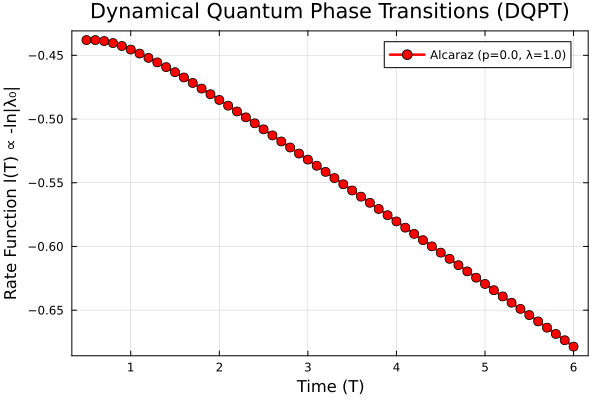

In [ ]:
# Use a dense array to ensure you don't step over the sharp kinks
dense_times = collect(0.5:0.1:6.0) 

dqpt_plot = plot_loschmidt_rate_function(
    expH_alcaraz, 
    dense_times;
    p = 0.0,            # Set to your desired quench parameters
    lambda = 1.0, 
    dt = 0.1,
    cutoff = 1e-10      # Keep this strict
)

display(dqpt_plot)

[PM LR|naiveRTM] L=64, cutoff=1.0e-10, maxdim=256, normalize=overlap)   1%  ETA: 0:02:50 (34.23 ms/it)
   Info: [28]  chi=6 | ds=3.6150580056126813e-6 | <R|Rprev> = -2.833844270355712e-14[ Info: PM Converged after 31 steps | ds=9.208443317865189e-7 | chi=6)
Computing Loschmidt Echo Rate... 100%|███████████████████| Time: 0:00:52


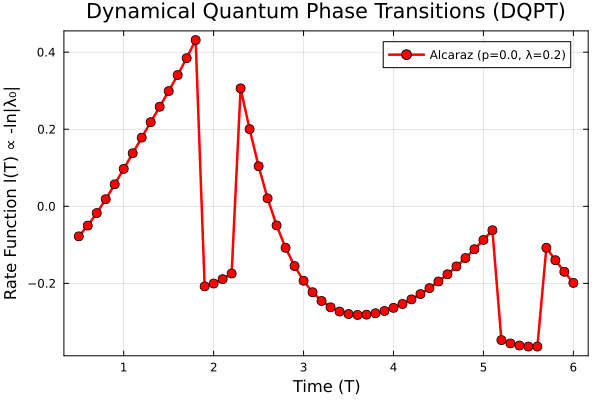

In [110]:
# Use a dense array to ensure you don't step over the sharp kinks
dense_times = collect(0.5:0.1:6.0) 

dqpt_plot = plot_loschmidt_rate_function(
    expH_alcaraz, 
    dense_times;
    p = 0.0,            # Set to your desired quench parameters
    lambda = 0.2, 
    dt = 0.1,
    cutoff = 1e-10      # Keep this strict
)

display(dqpt_plot)

The initial state we start our simulations with is the $|X+\rangle$ state. Physically, this is the exact ground state of a pure paramagnet (effectively an infinite transverse field, $\lambda \to \infty$). Therefore, our system always starts deep inside the Paramagnetic Phase.

When we run the simulation with a final Hamiltonian at $\lambda = 1.0$, we are quenching the system from the deep paramagnetic regime ($\lambda = \infty$) down to the critical point ($\lambda_c = 1.0$) and we stop exactly at the boundary, withour cross it. For quenches that remain within the same phase, or quenches that start or end exactly at the quantum critical point, the lines of Fisher zeroes in the complex time plane lie entirely in the negative half-plane. Because these zeroes never intersect the real-time axis, the Loschmidt echo rate function remains perfectly analytic and smooth (cite: Heyl et al 2013).

But when we set the final Hamiltonian to $\lambda = 0.2$, we force the initial paramagnetic state to evolve under a strongly ferromagnetic Hamiltonian, successfuly quenching the system across the quantum critical point. The fundamental signature of quenching across a quantum critical point is that the lines of Fisher zeroes are forced to cut across the complex plane into disconnected stripes. These lines now physically intersect the real-time axis. Every time our simulation time $T$ passes exactly through one of these intersections (the critical times $t_n^*$), the short-time expansion of the return probability breaks down. This mathematical breakdown manifests physically as the sharp, non-analytic "V-shaped" kinks we captured in your plot.

---
## DQPT-hunting with deflation — SUPERSEDED (history note)

The cells that were here hunted for a DQPT using the **single-vector deflated power method**
(`gen_exc1_right/left`, `compute_spectral_gap_LR` above) and the `analyze_alcaraz_dynamics_with_dqpt`
driver. As $T$ grew, the leading eigenvalue **blew up to $|\lambda_0|>1$** (e.g. ~2.2 near $T\approx6$,
unphysical) and the runs were abandoned (the original notes literally say *"bastante mierda, nos
olvidamos"*). 

**Diagnosis (resolved later):** this was a power-method **non-convergence artifact** at the
entanglement-barrier gap closing, not a DQPT — and for a quench *to* criticality there is no DQPT at
finite time anyway. The correct tool is the **block (subspace) power method**
(`block_transfer_eigs` in `dqpt_diagnostics.jl`), driven from `16_block_pm_alcaraz.ipynb` /
`17_ising_control.ipynb`; the CFT validation is in `18_cft_validation.ipynb`.

The deflation code above is kept as a **reference/fallback** (see CLAUDE.md §7). What follows is the
still-useful piece of this notebook: the **central-charge benchmark** via the Eq.(3) eigenvalue fit
(`extract_central_charge` / `run_cft_benchmark`), reused in notebook 18.


---

For the dominat eigenvalue lambda_0 we expect the CFT prediction: 
$$\frac{\text{Im}(\lambda_0)}{T} = a v - \frac{\kappa}{v T^2}$$

In [143]:
function extract_central_charge(target_times, lambda_0_vals; dt=0.1, v=2.0)
    T_arr = Float64.(target_times)
    
    # Extract Im(lambda0)/T 
    # y_c = abs.(imag.(lambda_0_vals)) ./ T_arr
    y_c = abs.(imag.(lambda_0_vals)) ./ T_arr

    
    # CFT fitting model: f(T) = a0 + a2/T² + a4/T⁴
    @. model_c(T, p) = p[1] + p[2]/(T^2)
    
    # Perform Fit
    p0_c = [1.0, 0.01] 
    fit_c = curve_fit(model_c, T_arr, y_c, p0_c)
    
    a0, a2 = fit_c.param
    
    # From the CFT mapping: a2 = (π * c * dt) / (24 * v)
    c_extracted = (24.0 * v * abs(a2)) / (pi * dt)
    
    println("Extracted Central Charge (c): ", round(c_extracted, digits=3))
    println("Expected c for standard Ising: 0.5\n")
    
    T_dense = range(minimum(T_arr), maximum(T_arr), length=200)
    
    plt_c = plot(
        T_arr, y_c, 
        seriestype=:scatter, marker=:circle, markersize=6, color=:blue, 
        label="Tensor Network Data",
        title="Extracting Central Charge (c)", 
        ylabel="|Im(lambda_0)| / T", 
        xlabel="Time (T)",
        grid=true, framestyle=:box
    )
    
    plot!(
        plt_c, T_dense, model_c(T_dense, fit_c.param), 
        lw=2.5, color=:red, 
        label="CFT Fit (c ≈ $(round(c_extracted, digits=2)))"
    )
    
    display(plt_c)
    
    return c_extracted
end

function run_cft_benchmark(mpo_generator::Function)
    p_val = 0.0         
    lambda_val = 1.0    
    dt_val = 0.05
    
    cft_times = collect(1.0:0.5:8.0) 
    L0_array = ComplexF64[]

    @showprogress for T in cft_times
        _, _, _, psi_L, psi_R, mpo = compute_alcaraz_entropies(
            mpo_generator, T; 
            lambda=lambda_val, p=p_val, dt=dt_val, cutoff=1e-10, maxdim=256, alg="RTM"
        )

        # Extract dominant eigenvalue
        overlap_0 = overlap_noconj(psi_L, psi_R)
        tau_0 = expval_LR(psi_L, mpo, psi_R) / overlap_0
        tau_0 = tau_0 / abs(tau_0)
        
        # Take complex log to get the intensive CFT scaling value
        lambda_0_cft = log(-Complex(tau_0))
        push!(L0_array, lambda_0_cft)
    end

    c_val = extract_central_charge(cft_times, L0_array; dt=dt_val, v=2.0)
    
    return c_val
end

run_cft_benchmark (generic function with 1 method)

[PM LR|RTM] L=164, cutoff=1.0e-10, maxdim=256, normalize=overlap)  13%  ETA: 0:05:44 (79.30 ms/it)
   Info: [668]  chi=7 | ds=0.0006695277812384104 | <R|Rprev> = -1.0590364832998524e-5┌ Warning: PM Stuck after 201/670 steps | ds=0.0009089682987922787 | chi=7)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151
Progress: 100%|█████████████████████████████████████████| Time: 0:04:11


Extracted Central Charge (c): 588.116
Expected c for standard Ising: 0.5



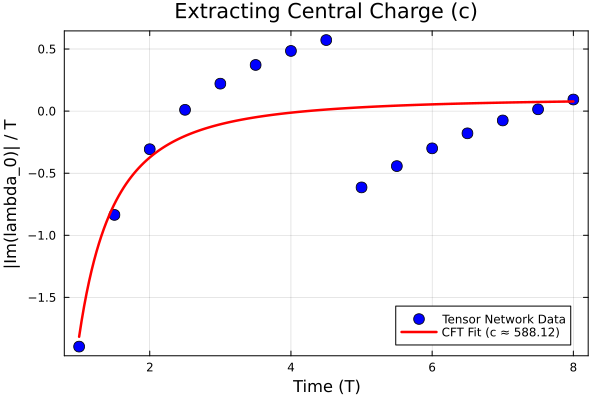

588.1156489659938

In [142]:
# Execute the pipeline
cft_central_charge = run_cft_benchmark(expH_alcaraz)

---